<a href="https://colab.research.google.com/github/Yogen4/Workshop.ai/blob/main/week4_workshop4_ai_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical

def load_dataset(folder):

    images = []
    labels = []

    for label in os.listdir(folder):
        path = os.path.join(folder, label)

        for img_file in os.listdir(path):
            img_path = os.path.join(path, img_file)

            img = Image.open(img_path).convert('L')
            img = img.resize((28,28))

            img = np.array(img) / 255.0   # normalize
            images.append(img)
            labels.append(int(label.split('_')[1]))

    return np.array(images), np.array(labels)


train_folder = "/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Train"
test_folder = "/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Test"

X_train, y_train = load_dataset(train_folder)
X_test, y_test = load_dataset(test_folder)


# Flatten images for FCN
X_train = X_train.reshape(X_train.shape[0], 784)
X_test = X_test.reshape(X_test.shape[0], 784)


# One-hot encode labels
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(64, activation='sigmoid', input_shape=(784,)))
model.add(Dense(128, activation='sigmoid'))
model.add(Dense(256, activation='sigmoid'))

model.add(Dense(10, activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)

earlystop = EarlyStopping(patience=5)

history = model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=[checkpoint, earlystop]
)

Epoch 1/20
40/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1621 - loss: 2.1582

43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.2405 - loss: 2.0384 - val_accuracy: 0.0066 - val_loss: 6.8269
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7522 - loss: 1.3430 - val_accuracy: 0.0066 - val_loss: 7.0343
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8928 - loss: 0.5779 - val_accuracy: 0.0066 - val_loss: 7.4850
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9547 - loss: 0.2730 - val_accuracy: 0.0066 - val_loss: 7.9930
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9679 - loss: 0.1538 - val_accuracy: 0.0066 - val_loss: 8.4618
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9779 - loss: 0.1045 - val_accuracy: 0.0066 - val_loss: 8.7112


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7007 - loss: 2.0683
Test Accuracy: 0.7006666660308838
Test Loss: 2.0682644844055176


In [ ]:
from tensorflow.keras.models import load_model

# Save
model.save("devnagari_model.h5")

# Load
loaded_model = load_model("devnagari_model.h5")

loss, acc = loaded_model.evaluate(X_test, y_test)

print("Loaded Model Accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7007 - loss: 2.0683
Loaded Model Accuracy: 0.7006666660308838


In [ ]:
predictions = loaded_model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

true_labels = np.argmax(y_test, axis=1)

print("Predicted:", predicted_labels[:10])
print("Actual:", true_labels[:10])

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted: [9 9 9 9 9 9 8 9 9 9]
Actual: [9 9 9 9 9 9 9 9 9 9]


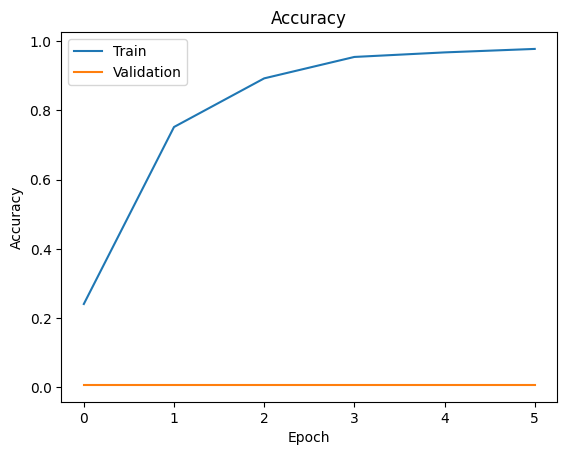

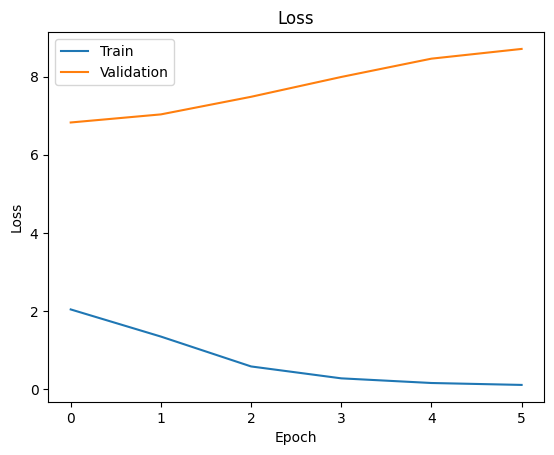

In [ ]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()